In [1]:
import pysam
import pandas as pd
import argparse
import sys
import re
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import numpy as np
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [2]:
def parse_args():
    parser = argparse.ArgumentParser(description='Extract specific fields from BAM file into a DataFrame')
    parser.add_argument('-i', '--input', required=True, help='Input BAM file')
    parser.add_argument('-o', '--output', help='Output CSV file (default: print to stdout)')
    parser.add_argument('-t', '--tag', default='GX', choices=['GX', 'GN'], 
                        help='Tag to extract feature from (GX or GN)')
    parser.add_argument('-s', '--separator', default='\t', help='Field separator for output')
    parser.add_argument('-l', '--limit', type=int, help='Limit number of rows to process')
    return parser.parse_args()

def extract_feature_from_id(sequence_id):
    """Extract the feature part from the sequence ID."""
    # Expected format: BARCODE:FEATURE:OTHER:PARTS
    parts = sequence_id.split(':')
    if len(parts) >= 2:
        # Extract just the feature name
        feature_with_number = parts[1]
        # Use regex to extract just the feature name (anything before _dup followed by digits)
        match = re.match(r'([^:]+)(?:_dup\d+)?', feature_with_number)
        if match:
            return match.group(1)
    return "Unknown"

def bam_to_dataframe(input_file, feature_tag='GX', limit=None):
    """Read BAM file and convert specified fields to a DataFrame."""
    data = []
    count = 0
    
    with pysam.AlignmentFile(input_file, "rb", threads=8) as bam:
        for read in bam:
            if limit is not None and count >= limit:
                break
                
            sequence_id = read.query_name
            mapping_quality = read.mapping_quality
            chromosome = read.reference_name
            start = read.reference_start  # 0-based inclusive
            end = read.reference_end      # 0-based exclusive

            # Extract mismatches from NM tag
            nm = read.get_tag('NM') if read.has_tag('NM') else 0
            
            # Extract local alignment score
            las = read.get_tag('AS') if read.has_tag('AS') else 0

            # Extract stellarscope posterior probabiliy score
            posterior = read.get_tag('XP') if read.has_tag('XP') else 0
            

            # Extract feature from GX or GN tag
            feature = read.get_tag(feature_tag) if read.has_tag(feature_tag) else "-"
            
            # Extract feature from sequence ID
            feature_match = re.search(r':([^:]+):', sequence_id)
            id_feature = feature_match.group(1) if feature_match else "Unknown"
            
            data.append({
                'sequenceID': sequence_id,
                'chromosome': chromosome,
                'start': start,
                'end': end,
                'feature_in_ID': id_feature,
                'quality': mapping_quality,
                f'{feature_tag}_tag': feature,
                'mismatches': nm,
                'las': las,
                'posterior': posterior
            })
            
            count += 1
    
    return pd.DataFrame(data)

def main():
    args = parse_args()
    
    try:
        df = bam_to_dataframe(args.input, args.tag, args.limit)
        
        if args.output:
            df.to_csv(args.output, sep=args.separator, index=False)
            print(f"Output written to {args.output}")
        else:
            print(df.to_csv(sep=args.separator, index=False))
            
    except Exception as e:
        sys.stderr.write(f"Error: {str(e)}\n")
        sys.exit(1)

In [3]:
dataset_id = "simulated_mm_RA"

# SoloTE upload

In [4]:
SoloTE_path = "/mnt/transfer/results/SoloTEout_thr0/"

In [ ]:
## Import SoloTE bam with all multi-mappers (OLD simulation)
# sample = "old"
# df_SoloTE_old = bam_to_dataframe(SoloTE_path + dataset_id + "/" + sample + "/" + sample + "_SoloTE_temp/"+sample+"_teannotated.bam", 
#                     limit=None)
# gc.collect()

In [ ]:
## Import SoloTE bam with all multi-mappers (YOUNG simulation)
# sample = "young"
# df_SoloTE_young = bam_to_dataframe(SoloTE_path + dataset_id + "/" + sample + "/" + sample + "_SoloTE_temp/"+sample+"_teannotated.bam", 
#                     limit=None)
# gc.collect()

In [14]:
#df_SoloTE_old.to_csv("data/df_SoloTE_old.csv")
df_SoloTE_old = pd.read_csv("data/df_SoloTE_old.csv")

#df_SoloTE_young.to_csv("data/df_SoloTE_young.csv")
df_SoloTE_young = pd.read_csv("data/df_SoloTE_young.csv")

# Stellarscope upload

In [4]:
stellarscope_path = "/mnt/transfer/results/stellarscope_out/"

## Stellarscope Old

Get primary mapping 

samtools view -b -F 0x100 old_pseudobulk-tmp_tele.bam > old_pseudobulk_primary_tele.bam

Best exclude filtering done with the 00_filter_stellarscope_bam_bestExclude.sh script available in this folder. Change to your stellarscope path:

./00_filter_stellarscope_bam_bestExclude.sh -p old -d stellarscope_out/simulated_mm_RA_pseudobulk_onestep/old 2>&1 | tee simulated_mm_RA_old_logfile.txt

In [5]:
sample = "old"

### Pre EM

Primary alignment obtained with 

samtools view -b -F 0x100 old_pseudobulk-tmp_tele.bam > old_pseudobulk_primary_tele.bam

In [ ]:
# Import bam pre EM (OLD simulation)
sample = "old"
df_Stellarscope_old_pre = bam_to_dataframe(stellarscope_path + dataset_id + "_pseudobulk_onestep/" + sample + "/" + sample + "_pseudobulk_primary_tele.bam", 
                                        feature_tag='ZF', limit=None)
gc.collect()

df_Stellarscope_old_pre[df_Stellarscope_old_pre["sequenceID"].duplicated()] # check that no reads are repeated

0

,sequenceID,chromosome,start,end,feature_in_ID,quality,ZF_tag,mismatches,las,posterior


In [10]:
df_Stellarscope_old_pre.to_csv("data/df_Stellarscope_old_pre_v1.5.csv")

### Post EM

In [11]:
# bam after EM, bestExclude strategy
df_Stellarscope_old_bestExclude = bam_to_dataframe(stellarscope_path + dataset_id + \
    "_pseudobulk_onestep/" + sample + "/" + sample + "_pseudobulk_bestExclude_vScript.bam", \
    feature_tag='ZF', limit=None)

df_Stellarscope_old_bestExclude['MAPQ_Pre'] = df_Stellarscope_old_bestExclude['sequenceID'].map(df_Stellarscope_old_pre.set_index('sequenceID')['quality'])

df_Stellarscope_old_bestExclude.shape

gc.collect()

(31717919, 11)

0

In [12]:
df_Stellarscope_old_bestExclude.to_csv("data/df_Stellarscope_old_bestExclude_v1.5.csv")

### Checkpoint

In [16]:
gc.collect()

0

In [15]:
df_Stellarscope_old_pre = pd.read_csv("data/df_Stellarscope_old_pre_v1.5.csv")
df_Stellarscope_old_bestExclude = pd.read_csv("data/df_Stellarscope_old_bestExclude_v1.5.csv")

### Filter by posterior

#### 0.5

In [26]:
df_Stellarscope_old_updated_05 = df_Stellarscope_old_bestExclude.loc[df_Stellarscope_old_bestExclude.posterior > 0.5,:].copy()
df_Stellarscope_old_updated_05.shape

(31701712, 12)

#### 0.9

In [27]:
df_Stellarscope_old_updated_09 = df_Stellarscope_old_updated_05.loc[df_Stellarscope_old_updated_05.posterior > 0.9,:].copy()
df_Stellarscope_old_updated_09.shape

(31655261, 12)

In [28]:
df_Stellarscope_old_updated_095 = df_Stellarscope_old_updated_09.loc[df_Stellarscope_old_updated_09.posterior > 0.95,:].copy()
df_Stellarscope_old_updated_095.shape

(31651295, 12)

#### 0.99

In [29]:
df_Stellarscope_old_updated_099 = df_Stellarscope_old_updated_095.loc[df_Stellarscope_old_updated_095.posterior > 0.99,:].copy()
df_Stellarscope_old_updated_099.shape

(31638664, 12)

### Check quality and posterior values

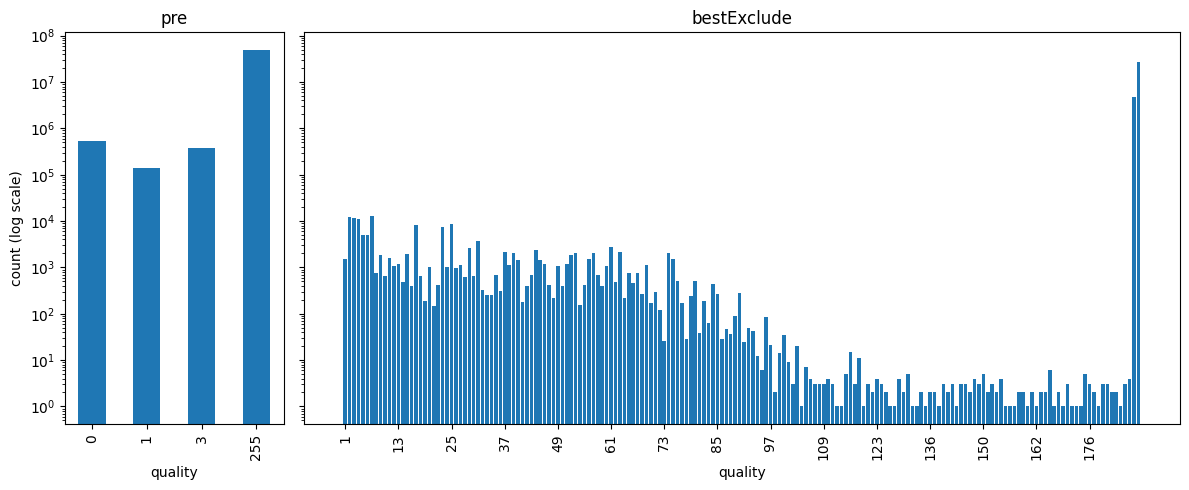

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True,
                          gridspec_kw={'width_ratios': [1, 4]})

vc_pre = df_Stellarscope_old_pre.quality.value_counts().sort_index()
vc_best = df_Stellarscope_old_bestExclude.quality.value_counts().sort_index()

vc_pre.plot(kind='bar', ax=axes[0], title='pre')

axes[1].bar(range(len(vc_best)), vc_best.values)
axes[1].set_title('bestExclude')

n_labels = 15
step = max(1, len(vc_best) // n_labels)
axes[1].set_xticks(range(0, len(vc_best), step))
axes[1].set_xticklabels(vc_best.index[::step], rotation=90)

for ax in axes:
    ax.set_yscale('log')
    ax.set_xlabel('quality')

axes[0].set_ylabel('count (log scale)')
plt.tight_layout()
plt.show();

### Posterior values

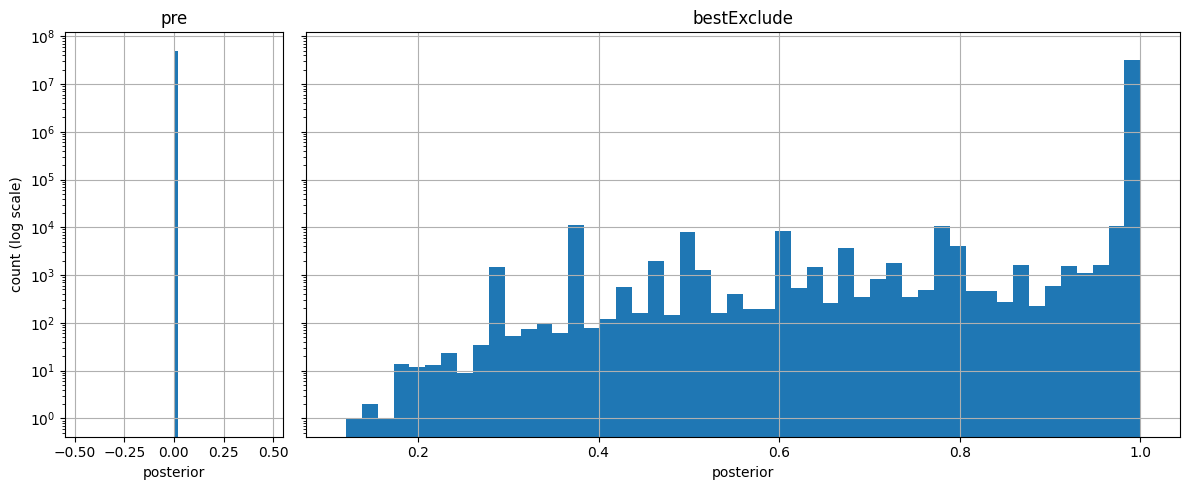

In [28]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True,
                          gridspec_kw={'width_ratios': [1, 4]})

df_Stellarscope_old_pre.posterior.hist(bins=50, ax=axes[0])
axes[0].set_title('pre')

df_Stellarscope_old_bestExclude.posterior.hist(bins=50, ax=axes[1])
axes[1].set_title('bestExclude')

for ax in axes:
    ax.set_yscale('log')
    ax.set_xlabel('posterior')

axes[0].set_ylabel('count (log scale)')
plt.tight_layout()
plt.show()
plt.close(fig);

### Df for plots

In [30]:
def add_correct_feature(df):
    """Label each read as correctly assigned, incorrectly assigned, or unmapped."""
    df['correct_feature'] = (df.feature_in_ID == df.ZF_tag)
    df.loc[df.ZF_tag == "-", 'correct_feature'] = "Unmapped"
    return df['correct_feature'].value_counts()

datasets = {
    'pre': df_Stellarscope_old_pre,
    'bestExclude': df_Stellarscope_old_bestExclude,
    'thr_0.5': df_Stellarscope_old_updated_05,
    'thr_0.9': df_Stellarscope_old_updated_09,
    'thr_0.95': df_Stellarscope_old_updated_095,
    'thr_0.99': df_Stellarscope_old_updated_099,
}

accuracy_counts = {name: add_correct_feature(df) for name, df in datasets.items()}

/mnt/transfer/tmp/ipykernel_2435296/2642475763.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Unmapped' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  df.loc[df.ZF_tag == "-", 'correct_feature'] = "Unmapped"
/mnt/transfer/tmp/ipykernel_2435296/2642475763.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Unmapped' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  df.loc[df.ZF_tag == "-", 'correct_feature'] = "Unmapped"
/mnt/transfer/tmp/ipykernel_2435296/2642475763.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Unmapped' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  df.loc[df.ZF_tag == "-", 'correct_feature'] = 

In [31]:
sns.set_context("talk")
sns.set_style("white")

def make_crosstab_long(df, quality_col, tool_label):
    """Crosstab correct_feature x quality column, reshape to long format, tag with tool name."""
    data = pd.crosstab(df.correct_feature, df[quality_col])
    data = data.reset_index().melt(id_vars='correct_feature', var_name='MappingQuality', value_name='Count')
    data['Tool'] = tool_label
    data = data.rename(columns={'correct_feature': 'MappingResult'})
    return data

# name -> (dataframe, quality column name, tool label)
datasets = {
    'pre':        (df_Stellarscope_old_pre,             'quality',  'oldTEs_StellarscopePreEM'),
    'bestExclude':(df_Stellarscope_old_bestExclude,      'MAPQ_Pre', 'oldTEs_Stellarscope_postEM_bestExclude'),
    'thr_0.5':    (df_Stellarscope_old_updated_05,       'MAPQ_Pre', 'oldTEs_Stellarscope_postEM_thr05'),
    'thr_0.9':    (df_Stellarscope_old_updated_09,       'MAPQ_Pre', 'oldTEs_Stellarscope_postEM_thr09'),
    'thr_0.95':   (df_Stellarscope_old_updated_095,      'MAPQ_Pre', 'oldTEs_Stellarscope_postEM_thr095'),
    'thr_0.99':   (df_Stellarscope_old_updated_099,      'MAPQ_Pre', 'oldTEs_Stellarscope_postEM_thr099'),
}

data_all_Stellarscope_old = pd.concat(
    [make_crosstab_long(df, qcol, label) for df, qcol, label in datasets.values()],
    ignore_index=True
)

data_all_Stellarscope_old.head()

,MappingResult,MappingQuality,Count,Tool
0,False,0,351845,oldTEs_StellarscopePreEM
1,True,0,191897,oldTEs_StellarscopePreEM
2,False,1,39072,oldTEs_StellarscopePreEM
3,True,1,99909,oldTEs_StellarscopePreEM
4,False,3,84326,oldTEs_StellarscopePreEM


<Axes: xlabel='Tool'>

Text(0.5, 1.0, 'Uniquely-mapped reads')

Text(0, 0.5, 'Read count')

Text(0.5, 0, 'Tool')

<Axes: xlabel='Tool'>

Text(0.5, 1.0, 'Multi-mapped reads')

Text(0, 0.5, 'Read count')

Text(0.5, 0, 'Tool')

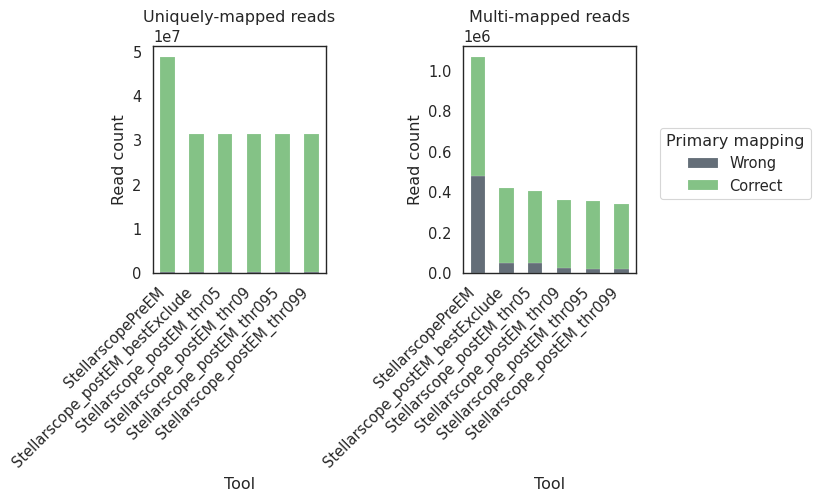

In [33]:
sns.set_context("paper", font_scale=1.2)

data_all_Stellarscope_old = data_all_Stellarscope_old.copy()
data_all_Stellarscope_old["Unique"] = (data_all_Stellarscope_old.MappingQuality == 255)

# Filter for "old" tools, excluding postEM (no bestExclude/threshold applied)
df = data_all_Stellarscope_old[
    data_all_Stellarscope_old['Tool'].str.startswith("old")
].copy()

df = df.loc[df['Tool'] != "oldTEs_Stellarscope_postEM", :]
df["Tool"] = df["Tool"].str.removeprefix("oldTEs_")

# Sanity check: confirm we only have the two MappingResult categories we plan to plot
unexpected = set(df['MappingResult'].unique()) - {True, False}
if unexpected:
    print(f"Warning: unexpected MappingResult categories found and excluded from plot: {unexpected}")
df = df[df['MappingResult'].isin([True, False])]

# Step 1 — aggregate counts
grouped = (
    df.groupby(["Tool", "Unique", "MappingResult"], as_index=False)["Count"]
    .sum()
)

# Step 2 — pivot for plotting (raw counts), explicit column order/selection
pivot = grouped.pivot_table(
    index=["Tool", "Unique"],
    columns="MappingResult",
    values="Count"
)
pivot = pivot.reindex(columns=[False, True])  # guarantee column order matches colors/labels below

# Step 3 — facet plotting
facet_order = [True, False]  # desired facet order
name_map = {False: "Multi", True: "Uniquely"}
color_map = {False: '#646E78', True: '#84C286'}   # False=Wrong, True=Correct
label_map = {False: "Wrong", True: "Correct"}

fig, axes = plt.subplots(1, 2, figsize=(7.5, 5), sharey=False)

for ax, unique_val in zip(axes, facet_order):
    subdf = pivot.xs(unique_val, level="Unique")
    subdf.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        color=[color_map[c] for c in subdf.columns],
        edgecolor="white",
        linewidth=0.1,
        legend=False  # suppress legends inside each subplot
    )
    ax.set_title(f"{name_map[unique_val]}-mapped reads")
    ax.set_ylabel("Read count")
    ax.set_xlabel("Tool")

    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha('right')

# Single shared legend, labels tied explicitly to the same column order as plotted
handles, _ = axes[0].get_legend_handles_labels()
legend_labels = [label_map[c] for c in pivot.columns]
fig.legend(
    handles, legend_labels,
    title="Primary mapping",
    loc="center left",
    bbox_to_anchor=(0.85, 0.69),
)

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.savefig("figures/mapping_results_comparison_facetMAPQ_old_v1.5.pdf",
            dpi=600, bbox_inches="tight")
plt.show()
plt.close(fig)

## Stellarscope Young

Get primary mapping:

samtools view -b -F 0x100 young_pseudobulk-tmp_tele.bam > young_pseudobulk_primary_tele.bam

Best exclude filtering (change to your stellarscope path):
./00_filter_stellarscope_bam_bestExclude.sh -p young -d stellarscope_out/simulated_mm_RA_pseudobulk_onestep/young 2>&1 | tee simulated_mm_RA_young_logfile.txt

### Pre EM

In [5]:
gc.collect()
dataset_id = "simulated_mm_RA"
sample = "young"

0

In [39]:
# Import bam pre EM (OLD simulation)
sample = "young"
df_Stellarscope_young_pre = bam_to_dataframe(stellarscope_path + dataset_id + "_pseudobulk_onestep/" + sample + "/" + sample + "_pseudobulk_primary_tele.bam", 
                                        feature_tag='ZF', limit=None)
gc.collect()

df_Stellarscope_young_pre[df_Stellarscope_young_pre["sequenceID"].duplicated()] # check that no reads are repeated

0

,sequenceID,chromosome,start,end,feature_in_ID,quality,ZF_tag,mismatches,las,posterior


In [40]:
df_Stellarscope_young_pre.to_csv("data/df_Stellarscope_young_pre_v1.5.csv")

In [10]:
df_Stellarscope_young_pre = pd.read_csv("data/df_Stellarscope_young_pre_v1.5.csv")


### Post EM

In [7]:
stellarscope_path = "/mnt/transfer/results/stellarscope_out/"

In [ ]:
# bam after EM, bestExclude strategy
df_Stellarscope_young_bestExclude = bam_to_dataframe(stellarscope_path + dataset_id + \
    "_pseudobulk_onestep/" + sample + "/" + sample + "_pseudobulk_bestExclude_vScript.bam", \
    feature_tag='ZF', limit=None) # this finished correctly

NameError: name 'df_Stellarscope_young_pre' is not defined

In [11]:

df_Stellarscope_young_bestExclude['MAPQ_Pre'] = df_Stellarscope_young_bestExclude['sequenceID'].map(df_Stellarscope_young_pre.set_index('sequenceID')['quality'])

df_Stellarscope_young_bestExclude.shape

gc.collect()

(23625039, 11)

826

In [12]:
df_Stellarscope_young_bestExclude.to_csv("data/df_Stellarscope_young_bestExclude_v1.5.csv")

### Checkpoint

In [13]:
gc.collect()

0

In [3]:
df_Stellarscope_young_bestExclude_oldversion = pd.read_csv("data/df_Stellarscope_young_bestExclude.csv")

In [2]:
df_Stellarscope_young_pre = pd.read_csv("data/df_Stellarscope_young_pre_v1.5.csv")
df_Stellarscope_young_bestExclude = pd.read_csv("data/df_Stellarscope_young_bestExclude_v1.5.csv")

In [6]:
df_Stellarscope_young_bestExclude_oldversion.shape
df_Stellarscope_young_bestExclude.shape
oldfeatures = df_Stellarscope_young_bestExclude_oldversion.ZF_tag.unique()
newfeatures = df_Stellarscope_young_bestExclude.ZF_tag.unique()

(23597869, 12)

(23625039, 12)

In [11]:
len(oldfeatures)
len(newfeatures)
np.intersect(oldfeatures, newfeatures)

63733

63723

AttributeError: module 'numpy' has no attribute 'intersect'

In [17]:
# Each sequenceID should appear exactly once
assert df_Stellarscope_young_bestExclude['sequenceID'].nunique() == len(df_Stellarscope_young_bestExclude)

### Filter by posterior

#### 0.5

In [18]:
df_Stellarscope_young_updated_05 = df_Stellarscope_young_bestExclude.loc[df_Stellarscope_young_bestExclude.posterior > 0.5, :].copy()
df_Stellarscope_young_updated_05.shape

(21394107, 11)

In [19]:

df_Stellarscope_young_updated_05.posterior.describe()
df_Stellarscope_young_updated_05.MAPQ_Pre.value_counts()


count    2.139411e+07
mean     9.198901e-01
std      1.397774e-01
min      5.000010e-01
25%      9.205490e-01
50%      9.976520e-01
75%      9.999980e-01
max      1.000000e+00
Name: posterior, dtype: float64

MAPQ_Pre
0      13166400
255     3918244
3       2441951
1       1867512
Name: count, dtype: int64

#### 0.9

In [ ]:
df_Stellarscope_young_updated_09 = df_Stellarscope_young_updated_05.loc[df_Stellarscope_young_updated_05.posterior > 0.9, :].copy()

#### 0.95

In [21]:
df_Stellarscope_young_updated_095 = df_Stellarscope_young_updated_09.loc[df_Stellarscope_young_updated_09.posterior > 0.95,:].copy()
df_Stellarscope_young_updated_095

,sequenceID,chromosome,start,end,feature_in_ID,quality,ZF_tag,mismatches,las,posterior,MAPQ_Pre
0,GTAACTGAGATAGCATTTGCTCAGAC:B2_Mm1a_dup7283:77:...,chr7,80702218,80702318,B2_Mm1a_dup7283,50,B2_Mm1a_dup7283,0,98,0.999990,0
2,AACGTTGAGGCTAGACCCGAACCGTG:MERVL-int_dup420:82...,chr3,54169103,54169203,MERVL-int_dup420,193,MERVL-int_dup420,0,98,1.000000,255
4,AAACCTGCAGCCTATAGAGGCGTTCC:B2_Mm1a_dup14827:41...,chr14,73582909,73583009,B2_Mm1a_dup14827,26,B2_Mm1a_dup14827,0,98,0.997381,0
6,AAACCTGCAGCCTATAAAAAAACCTG:ETnERV-int_dup796:6...,KK082441.1,19719,19819,ETnERV-int_dup796,23,__no_feature,1,96,0.995515,0
7,AAACCTGCAGCCTATAAAAAAAGCTT:RLTRETN_Mm_dup461:2...,chr7,4057793,4057893,RLTRETN_Mm_dup461,32,RLTRETN_Mm_dup461,0,98,0.999355,0
...,...,...,...,...,...,...,...,...,...,...,...
23625034,CGTGTCTGTGGTTTCAGTCTGTCCCA:RLTR10-int_dup1317:...,chrX,58845761,58845861,RLTR10-int_dup1317,76,RLTR10-int_dup1317,1,96,1.000000,3
23625035,ACTGTCCGTTTAAGCCACTCGCGATA:B1_Mus2_dup50716:14...,chr6,136826315,136826415,B1_Mus2_dup50716,42,B1_Mus2_dup25418,1,97,0.999939,3
23625036,TTTGTCAAGGGTCGATCCGAGTATTC:IAPLTR1_Mm_dup385:8...,chr4,117696266,117696366,IAPLTR1_Mm_dup385,30,IAPLTR1_Mm_dup385,0,98,0.998885,0
23625037,TTTGTCAAGGGTCGATGAATATCCCT:MMERGLN_LTR_dup281:...,JH792828.1,13393,13493,MMERGLN_LTR_dup281,18,__no_feature,0,98,0.982471,0


#### 0.99

In [ ]:
df_Stellarscope_young_updated_099 = df_Stellarscope_young_updated_095.loc[df_Stellarscope_young_updated_095.posterior > 0.99,:].copy()
df_Stellarscope_young_updated_099.shape

(12547924, 11)

### Check quality and posterior values

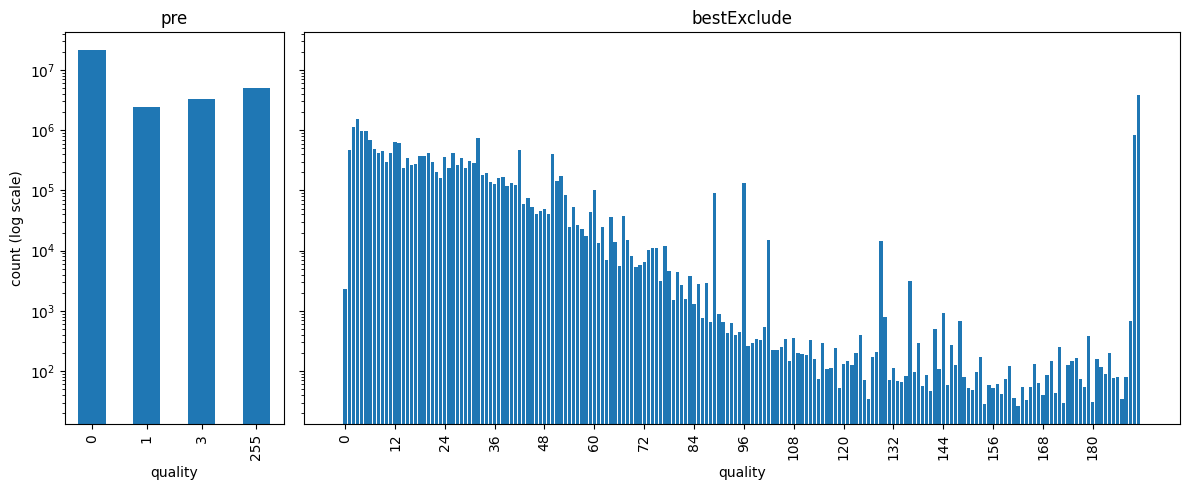

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True,
                          gridspec_kw={'width_ratios': [1, 4]})

vc_pre = df_Stellarscope_young_pre.quality.value_counts().sort_index()
vc_best = df_Stellarscope_young_bestExclude.quality.value_counts().sort_index()

vc_pre.plot(kind='bar', ax=axes[0], title='pre')

axes[1].bar(range(len(vc_best)), vc_best.values)
axes[1].set_title('bestExclude')

n_labels = 15
step = max(1, len(vc_best) // n_labels)
axes[1].set_xticks(range(0, len(vc_best), step))
axes[1].set_xticklabels(vc_best.index[::step], rotation=90)

for ax in axes:
    ax.set_yscale('log')
    ax.set_xlabel('quality')

axes[0].set_ylabel('count (log scale)')
plt.tight_layout()
plt.show();

### Posterior values

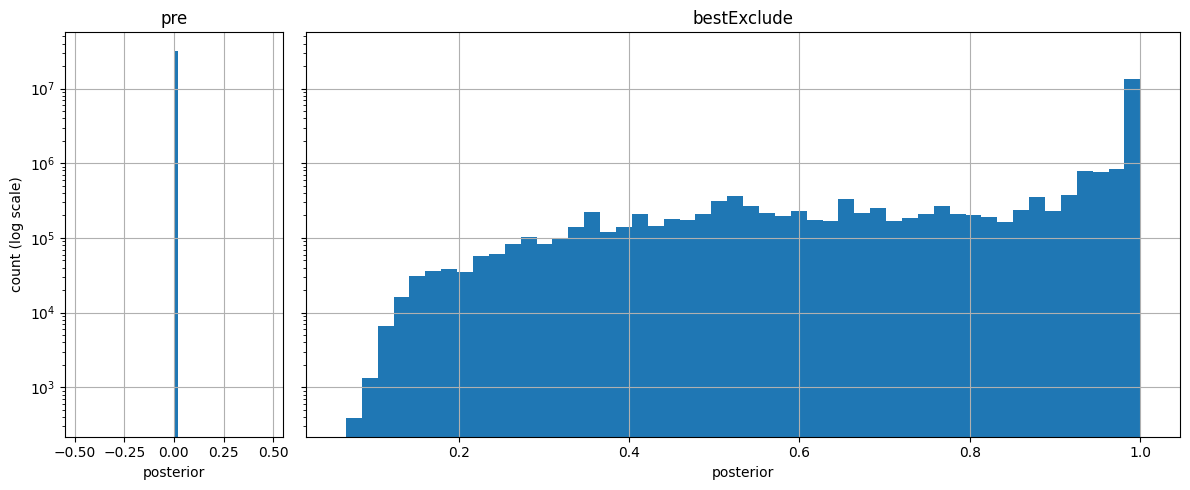

In [32]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True,
                          gridspec_kw={'width_ratios': [1, 4]})

df_Stellarscope_young_pre.posterior.hist(bins=50, ax=axes[0])
axes[0].set_title('pre')

df_Stellarscope_young_bestExclude.posterior.hist(bins=50, ax=axes[1])
axes[1].set_title('bestExclude')

for ax in axes:
    ax.set_yscale('log')
    ax.set_xlabel('posterior')

axes[0].set_ylabel('count (log scale)')
plt.tight_layout()
plt.show()
plt.close(fig);

# Comparison

In [23]:
# conversion table
conversion_table = pd.read_csv("/mnt/transfer/TEbenchmarking/Rscripts/annotation/annotation_mm10_conversion_withAge.tsv", 
                        sep=" ")
conversion_table.head

<bound method NDFrame.head of                 chr    start      end strand  sw_score  \
1              chr1  3000001  3002128      -   12955.0   
2              chr1  3003153  3003994      -    1216.0   
3              chr1  3003994  3004054      -     234.0   
4              chr1  3004041  3004206      +    3685.0   
5              chr1  3004271  3005001      +    3685.0   
...             ...      ...      ...    ...       ...   
3727448  JH584304.1    66452    66509      -     243.0   
3727449  JH584304.1    66512    67008      +    1749.0   
3727450  JH584304.1    67039    67179      -     841.0   
3727451  JH584304.1    67180    67389      +    1503.0   
3727452  JH584304.1    67398   114452      -    3390.0   

                           locusID     family          subfamily      class  \
1                    L1_Mus3_dup24         L1            L1-Mus3       LINE   
2                      L1Md_F_dup2         L1             L1Md-F       LINE   
3                    L1_Mus3_dup25  

## Check if the mapped feature is correct

### SoloTE

In [24]:
# # check that the mapped feature is correct 

# SoloTE
# check that all the names match
df_SoloTE_old['GX_tag'].isin(conversion_table.soloTE_name).value_counts()
# convert SoloTE id in locus id
# Create a mapping from df2
id_to_soloTE = conversion_table.dropna().drop_duplicates('soloTE_name', keep='last').set_index('soloTE_name')['locusID']
id_to_soloTE
# Map to df1
df_SoloTE_old['locusID'] = df_SoloTE_old['GX_tag'].map(id_to_soloTE)
df_SoloTE_old['correct_feature'] = (df_SoloTE_old.feature_in_ID == df_SoloTE_old.locusID)
df_SoloTE_old['correct_feature'].value_counts()

# SoloTE
# check that all the names match
df_SoloTE_young['GX_tag'].isin(conversion_table.soloTE_name).value_counts()
# convert SoloTE id in locus id
# Create a mapping from df2
id_to_soloTE = conversion_table.dropna().drop_duplicates('soloTE_name', keep='last').set_index('soloTE_name')['locusID']
id_to_soloTE
# Map to df1
df_SoloTE_young['locusID'] = df_SoloTE_young['GX_tag'].map(id_to_soloTE)
df_SoloTE_young['correct_feature'] = (df_SoloTE_young.feature_in_ID == df_SoloTE_young.locusID)
df_SoloTE_young['correct_feature'].value_counts()


GX_tag
True    50292638
Name: count, dtype: int64

soloTE_name
chr1|3000001|3002128|L1_Mus3:L1:LINE|10.5|-                L1_Mus3_dup24
chr1|3003153|3003994|L1Md_F:L1:LINE|26.8|-                   L1Md_F_dup2
chr1|3003994|3004054|L1_Mus3:L1:LINE|27.9|-                L1_Mus3_dup25
chr1|3004041|3004206|L1_Rod:L1:LINE|19.9|+                   L1_Rod_dup1
chr1|3004271|3005001|L1_Rod:L1:LINE|19.9|+                   L1_Rod_dup2
                                                              ...       
chrY|90838013|90838289|L1MA7:L1:LINE|27.4|-                L1MA7_dup1866
chrY|90838300|90838481|MLT1E2:ERVL-MaLR:LTR|29.4|-        MLT1E2_dup1082
chrY|90838555|90838722|MLT1E2:ERVL-MaLR:LTR|36.3|-        MLT1E2_dup1083
chrY|90843305|90843490|MER58A:hAT-Charlie:DNA|33.0|+      MER58A_dup2178
chrY|90844254|90844442|B2_Mm1a:B2:SINE|1.1|-            B2_Mm1a_dup10426
Name: locusID, Length: 3652262, dtype: object

correct_feature
True     48866203
False     1426435
Name: count, dtype: int64

GX_tag
True    31951408
Name: count, dtype: int64

soloTE_name
chr1|3000001|3002128|L1_Mus3:L1:LINE|10.5|-                L1_Mus3_dup24
chr1|3003153|3003994|L1Md_F:L1:LINE|26.8|-                   L1Md_F_dup2
chr1|3003994|3004054|L1_Mus3:L1:LINE|27.9|-                L1_Mus3_dup25
chr1|3004041|3004206|L1_Rod:L1:LINE|19.9|+                   L1_Rod_dup1
chr1|3004271|3005001|L1_Rod:L1:LINE|19.9|+                   L1_Rod_dup2
                                                              ...       
chrY|90838013|90838289|L1MA7:L1:LINE|27.4|-                L1MA7_dup1866
chrY|90838300|90838481|MLT1E2:ERVL-MaLR:LTR|29.4|-        MLT1E2_dup1082
chrY|90838555|90838722|MLT1E2:ERVL-MaLR:LTR|36.3|-        MLT1E2_dup1083
chrY|90843305|90843490|MER58A:hAT-Charlie:DNA|33.0|+      MER58A_dup2178
chrY|90844254|90844442|B2_Mm1a:B2:SINE|1.1|-            B2_Mm1a_dup10426
Name: locusID, Length: 3652262, dtype: object

correct_feature
False    18270104
True     13681304
Name: count, dtype: int64

### Stellarscope

In [33]:
# Define all dataframes to process
dataframes = {
    'Stellarscope_old_pre': df_Stellarscope_old_pre,
    'Stellarscope_old_bestExclude': df_Stellarscope_old_bestExclude,
    'Stellarscope_old_updated_05': df_Stellarscope_old_updated_05,
    'Stellarscope_old_updated_09': df_Stellarscope_old_updated_09,
    'Stellarscope_old_updated_095': df_Stellarscope_old_updated_095,
    'Stellarscope_old_updated_099': df_Stellarscope_old_updated_099,
    'Stellarscope_young_pre': df_Stellarscope_young_pre,
    'Stellarscope_young_bestExclude': df_Stellarscope_young_bestExclude,
    'Stellarscope_young_updated_05': df_Stellarscope_young_updated_05,
    'Stellarscope_young_updated_09': df_Stellarscope_young_updated_09,
    'Stellarscope_young_updated_095': df_Stellarscope_young_updated_095,
    'Stellarscope_young_updated_099': df_Stellarscope_young_updated_099,
}

# Process all dataframes
for name, df in dataframes.items():
    # Use np.where for conditional assignment
    df['correct_feature'] = np.where(
        df['ZF_tag'] == "-",
        "Unmapped",
        df['feature_in_ID'] == df['ZF_tag']
    )
    
    # Print results
    print(f"\n{name}:")
    print(df['correct_feature'].value_counts())


Stellarscope_old_pre:
correct_feature
True     49271438
False      572221
Name: count, dtype: int64

Stellarscope_old_bestExclude:
correct_feature
True     31592785
False      125134
Name: count, dtype: int64

Stellarscope_old_updated_05:
correct_feature
True     31578279
False      123433
Name: count, dtype: int64

Stellarscope_old_updated_09:
correct_feature
True     31557505
False       97756
Name: count, dtype: int64

Stellarscope_old_updated_095:
correct_feature
True     31555341
False       95954
Name: count, dtype: int64

Stellarscope_old_updated_099:
correct_feature
True     31544877
False       93787
Name: count, dtype: int64

Stellarscope_young_pre:
correct_feature
False    18191609
True     13897367
Name: count, dtype: int64

Stellarscope_young_bestExclude:
correct_feature
False    12393453
True     11231586
Name: count, dtype: int64

Stellarscope_young_updated_05:
correct_feature
True     10996798
False    10397309
Name: count, dtype: int64

Stellarscope_young_updated_09:


In [34]:
# Define dataframes with their configurations
datasets = [
    {'df': df_SoloTE_old, 'tool': 'oldTEs_SoloTE', 'quality_col': 'quality'},
    {'df': df_SoloTE_young, 'tool': 'youngTEs_SoloTE', 'quality_col': 'quality'},
    {'df': df_Stellarscope_old_pre, 'tool': 'oldTEs_Stellarscope_PreEM', 'quality_col': 'quality'},
    {'df': df_Stellarscope_old_bestExclude, 'tool': 'oldTEs_Stellarscope_postEM_bestExclude', 'quality_col': 'MAPQ_Pre'},
    {'df': df_Stellarscope_old_updated_05, 'tool': 'oldTEs_Stellarscope_postEM_thr05', 'quality_col': 'MAPQ_Pre'},
    {'df': df_Stellarscope_old_updated_09, 'tool': 'oldTEs_Stellarscope_postEM_thr09', 'quality_col': 'MAPQ_Pre'},
    {'df': df_Stellarscope_old_updated_095, 'tool': 'oldTEs_Stellarscope_postEM_thr095', 'quality_col': 'MAPQ_Pre'},
    {'df': df_Stellarscope_old_updated_099, 'tool': 'oldTEs_Stellarscope_postEM_thr099', 'quality_col': 'MAPQ_Pre'},
    {'df': df_Stellarscope_young_pre, 'tool': 'youngTEs_Stellarscope_PreEM', 'quality_col': 'quality'},
    {'df': df_Stellarscope_young_bestExclude, 'tool': 'youngTEs_Stellarscope_postEM_bestExclude', 'quality_col': 'MAPQ_Pre'},
    {'df': df_Stellarscope_young_updated_05, 'tool': 'youngTEs_Stellarscope_postEM_thr05', 'quality_col': 'MAPQ_Pre'},
    {'df': df_Stellarscope_young_updated_09, 'tool': 'youngTEs_Stellarscope_postEM_thr09', 'quality_col': 'MAPQ_Pre'},
    {'df': df_Stellarscope_young_updated_095, 'tool': 'youngTEs_Stellarscope_postEM_thr095', 'quality_col': 'MAPQ_Pre'},
    {'df': df_Stellarscope_young_updated_099, 'tool': 'youngTEs_Stellarscope_postEM_thr099', 'quality_col': 'MAPQ_Pre'},
]

# Process all datasets
data_list = []

for config in datasets:
    # Create crosstab
    data = pd.crosstab(config['df'].correct_feature, config['df'][config['quality_col']])
    
    # Reshape and add metadata
    data = (data.reset_index()
            .melt(id_vars='correct_feature', var_name='MappingQuality', value_name='Count')
            .rename(columns={'correct_feature': 'MappingResult'})
            .assign(Tool=config['tool'])
                        .assign(Tool=config['tool'],
                    Unique=lambda x: x['MappingQuality'] == 255))
    
    data_list.append(data)

# Combine all data
data_all = pd.concat(data_list, ignore_index=True)

# Convert MappingResult to consistent boolean type
data_all['MappingResult'] = data_all['MappingResult'].map({
    True: True,
    False: False,
    'True': True,
    'False': False
})

print(f"Total rows: {len(data_all)}")
print(f"Tools: {data_all['Tool'].nunique()}")
data_all.head()

Total rows: 112
Tools: 14


,MappingResult,MappingQuality,Count,Tool,Unique
0,False,0,355600,oldTEs_SoloTE,False
1,True,0,191711,oldTEs_SoloTE,False
2,False,1,39437,oldTEs_SoloTE,False
3,True,1,99901,oldTEs_SoloTE,False
4,False,3,81568,oldTEs_SoloTE,False


In [35]:
data_all.to_csv("data/df_forPlotting_mouseRAsimulation_260708_v1.5.csv")

# checkpoint before plotting

In [ ]:
# data_all.to_csv("data/df_forPlotting_mouseRAsimulation_SoloTEvsStellarscope.csv")
data_all = pd.read_csv("data/df_forPlotting_mouseRAsimulation_260708_v1.5.csv")

In [36]:
data_all

,MappingResult,MappingQuality,Count,Tool,Unique
0,False,0,355600,oldTEs_SoloTE,False
1,True,0,191711,oldTEs_SoloTE,False
2,False,1,39437,oldTEs_SoloTE,False
3,True,1,99901,oldTEs_SoloTE,False
4,False,3,81568,oldTEs_SoloTE,False
...,...,...,...,...,...
107,True,1,987370,youngTEs_Stellarscope_postEM_thr099,False
108,False,3,747017,youngTEs_Stellarscope_postEM_thr099,False
109,True,3,1244855,youngTEs_Stellarscope_postEM_thr099,False
110,False,255,650090,youngTEs_Stellarscope_postEM_thr099,True


### All tools and ages

<Axes: xlabel='Tool'>

Text(0, 0.5, 'Count')

Text(0.5, 0, 'Tool')

Text(0.5, 1.0, 'Mapping Results by Tool')

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13]),
 [Text(0, 0, 'oldTEs_SoloTE'),
  Text(1, 0, 'oldTEs_Stellarscope_PreEM'),
  Text(2, 0, 'oldTEs_Stellarscope_postEM_bestExclude'),
  Text(3, 0, 'oldTEs_Stellarscope_postEM_thr05'),
  Text(4, 0, 'oldTEs_Stellarscope_postEM_thr09'),
  Text(5, 0, 'oldTEs_Stellarscope_postEM_thr095'),
  Text(6, 0, 'oldTEs_Stellarscope_postEM_thr099'),
  Text(7, 0, 'youngTEs_SoloTE'),
  Text(8, 0, 'youngTEs_Stellarscope_PreEM'),
  Text(9, 0, 'youngTEs_Stellarscope_postEM_bestExclude'),
  Text(10, 0, 'youngTEs_Stellarscope_postEM_thr05'),
  Text(11, 0, 'youngTEs_Stellarscope_postEM_thr09'),
  Text(12, 0, 'youngTEs_Stellarscope_postEM_thr095'),
  Text(13, 0, 'youngTEs_Stellarscope_postEM_thr099')])

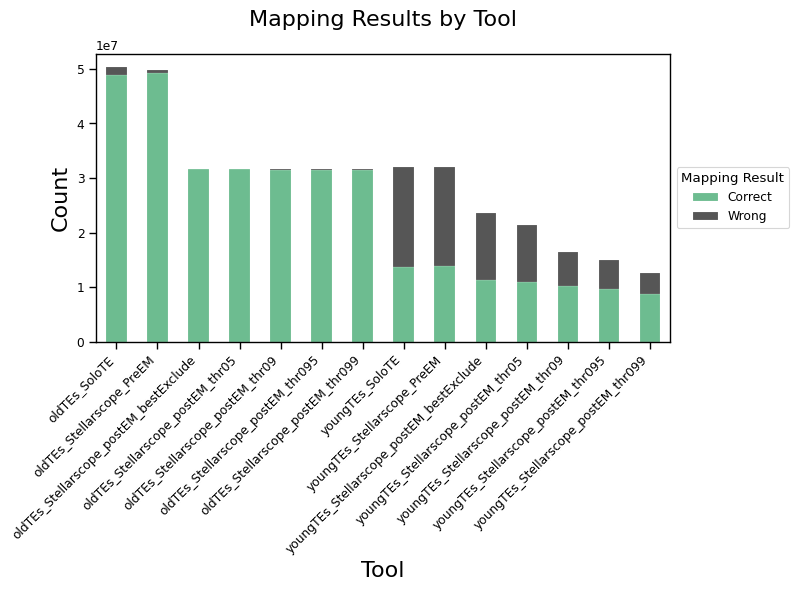

In [37]:
sns.set_context("paper")

pivot = (data_all
         .groupby(['Tool', 'MappingResult'])['Count']
         .sum()
         .reset_index()
         .pivot(index='Tool', columns='MappingResult', values='Count')
         .fillna(0)
         .rename(columns={True: 'Correct', False: 'Wrong'})
         [['Correct', 'Wrong']])

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

pivot.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=['#6dbc90', '#565656'],
    edgecolor='white',
    linewidth=0.1,
    legend=False  # Disable default legend
)

ax.set_ylabel('Count', fontsize=16)
ax.set_xlabel('Tool', fontsize=16)
ax.set_title('Mapping Results by Tool', fontsize=16, pad=20)

# Add legend to the right
ax.legend(
    ['Correct', 'Wrong'],
    title='Mapping Result',
    loc='center left',
    bbox_to_anchor=(1.0, 0.5),
    frameon=True
)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.savefig('figures/mapping_results_by_tool_withBestExclude.pdf', 
            dpi=600, bbox_inches='tight')
plt.show()

### Old simulation

<Axes: xlabel='Tool'>

Text(0.5, 1.0, 'Uniquely-mapped reads')

Text(0, 0.5, 'Read count')

Text(0.5, 0, 'Tool')

<Axes: xlabel='Tool'>

Text(0.5, 1.0, 'Multi-mapped reads')

Text(0, 0.5, 'Read count')

Text(0.5, 0, 'Tool')

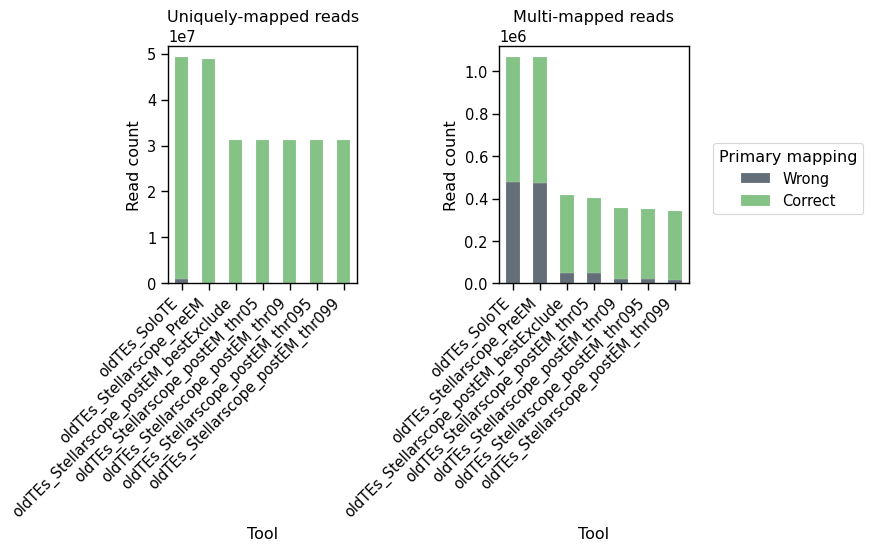

In [38]:
sns.set_context("paper", font_scale=1.2)
# Filter for "young" tools
df = data_all[data_all['Tool'].str.startswith("old")]
# Step 1 — aggregate counts
grouped = (
    df.groupby(["Tool", "Unique", "MappingResult"], as_index=False)["Count"]
    .sum()
)

# Step 2 — pivot for plotting (raw counts)
pivot = grouped.pivot_table(
    index=["Tool", "Unique"],
    columns="MappingResult",
    values="Count"
)

# Step 3 — facet plotting
facet_order = [True, False]  # your desired facet order
name_map = {False: "Multi", True: "Uniquely"}

fig, axes = plt.subplots(1, 2, figsize=(8, 5.5), sharey=False)

for ax, unique_val in zip(axes, facet_order):
    subdf = pivot.xs(unique_val, level="Unique")
    subdf.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        color=['#646E78', '#84C286'],
        edgecolor="white",
        linewidth=0.1,
        legend=False  # suppress legends inside each subplot
    )
    ax.set_title(f"{name_map[unique_val]}-mapped reads")
    ax.set_ylabel("Read count")
    ax.set_xlabel("Tool")

    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha('right')

# Create a single shared legend on the right
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, ["Wrong", "Correct"],
    title="Primary mapping",
    loc="center left",
    bbox_to_anchor=(0.85, 0.69),  # right side, vertically centered
)

plt.tight_layout(rect=[0, 0, 0.85, 1])  # leave space for the legend
plt.savefig("figures/mapping_results_comparison_facetMAPQ_counts_old_withBestExclude.pdf",
            dpi=600, bbox_inches="tight")
plt.show()


<Axes: xlabel='Tool'>

Text(0.5, 1.0, 'Multi-mapped reads')

Text(0, 0.5, 'Percentage of reads')

Text(0.5, 0, 'Tool')

<Axes: xlabel='Tool'>

Text(0.5, 1.0, 'Uniquely-mapped reads')

Text(0, 0.5, 'Percentage of reads')

Text(0.5, 0, 'Tool')

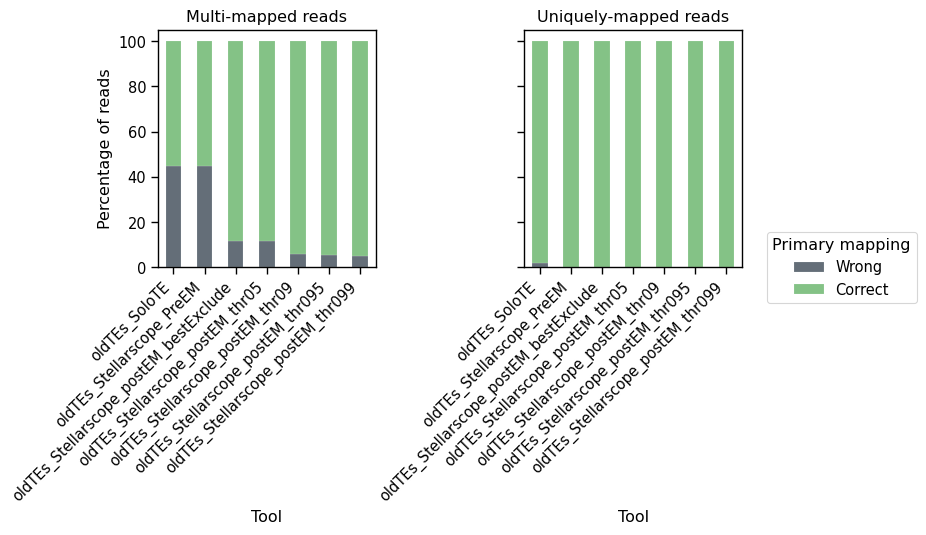

In [39]:
sns.set_context("paper", font_scale=1.2)

# Step 1 — aggregate counts
grouped = (
    df.groupby(["Tool", "Unique", "MappingResult"], as_index=False)["Count"]
    .sum()
)

# Step 2 — normalize to percentage per Tool+Unique
grouped["Percentage"] = (
    grouped.groupby(["Tool", "Unique"])["Count"]
    .transform(lambda x: 100 * x / x.sum())
)

# Step 3 — pivot for plotting
pivot = grouped.pivot_table(
    index=["Tool", "Unique"],
    columns="MappingResult",
    values="Percentage"
)

# Step 4 — facet plotting
facet_order = [False, True]
name_map = {False: "Multi", True: "Uniquely"}

fig, axes = plt.subplots(1, 2, figsize=(7.5, 5.5), sharey=True)

for ax, unique_val in zip(axes, facet_order):
    subdf = pivot.xs(unique_val, level="Unique")
    subdf.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        color=['#646E78', '#84C286'],
        edgecolor="white",
        linewidth=0.1
    )
    ax.set_title(f"{name_map[unique_val]}-mapped reads")
    ax.set_ylabel("Percentage of reads")
    ax.set_xlabel("Tool")

    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha('right')

    ax.legend_.remove()  # remove legend from each subplot

# Add single legend to the right of the figure
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(
    handles, ["Wrong", "Correct"],
    title="Primary mapping",
    loc="center left",
    bbox_to_anchor=(1.0, 0.5)
)

plt.tight_layout()
plt.savefig("figures/mapping_results_comparison_facetMAPQ_percentage_withBestExclude.pdf", dpi=600, bbox_inches="tight")
plt.show()

### Young

/mnt/transfer/tmp/ipykernel_3056246/1291480508.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Tool"] = df["Tool"].str.removeprefix("youngTEs_")


<Axes: xlabel='Tool'>

Text(0.5, 1.0, 'Uniquely-mapped reads')

Text(0, 0.5, 'Read count')

Text(0.5, 0, 'Tool')

<Axes: xlabel='Tool'>

Text(0.5, 1.0, 'Multi-mapped reads')

Text(0, 0.5, 'Read count')

Text(0.5, 0, 'Tool')

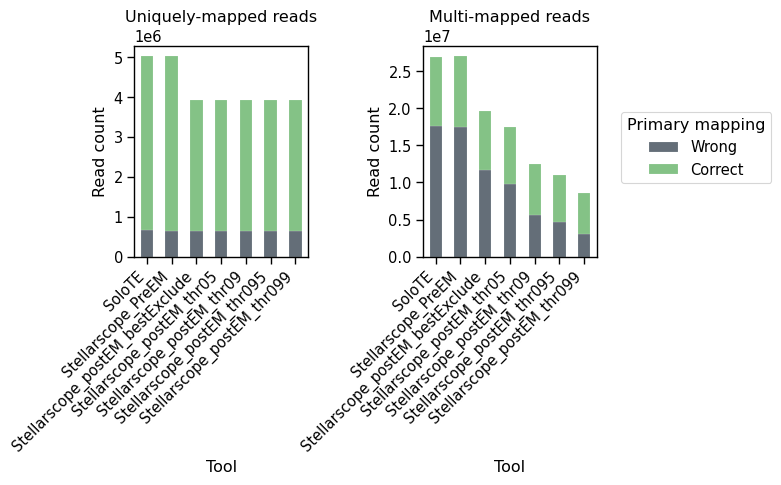

In [40]:
sns.set_context("paper", font_scale=1.2)

# Filter for "young" tools
df = data_all[data_all['Tool'].str.startswith("young")]
df["Tool"] = df["Tool"].str.removeprefix("youngTEs_")
# Step 1 — aggregate counts
grouped = (
    df.groupby(["Tool", "Unique", "MappingResult"], as_index=False)["Count"]
    .sum()
)

# Step 2 — pivot for plotting (raw counts)
pivot = grouped.pivot_table(
    index=["Tool", "Unique"],
    columns="MappingResult",
    values="Count"
)

# Step 3 — facet plotting
facet_order = [True, False]  # your desired facet order
name_map = {False: "Multi", True: "Uniquely"}

fig, axes = plt.subplots(1, 2, figsize=(7, 5), sharey=False)

for ax, unique_val in zip(axes, facet_order):
    subdf = pivot.xs(unique_val, level="Unique")
    subdf.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        color=['#646E78', '#84C286'],
        edgecolor="white",
        linewidth=0.1,
        legend=False  # suppress legends inside each subplot
    )
    ax.set_title(f"{name_map[unique_val]}-mapped reads")
    ax.set_ylabel("Read count")
    ax.set_xlabel("Tool")

    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha('right')

# Create a single shared legend on the right
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, ["Wrong", "Correct"],
    title="Primary mapping",
    loc="center left",
    bbox_to_anchor=(0.85, 0.69),  # right side, vertically centered
)

plt.tight_layout(rect=[0, 0, 0.85, 1])  # leave space for the legend
plt.savefig("figures/mapping_results_comparison_facetMAPQ_counts_young_withBestExclude.pdf",
            dpi=600, bbox_inches="tight")
plt.show()
